100%|█████████████████████████████████████████████████████████████████████████████████████| 8.91k/8.91k [00:00<?, ?B/s]

Extracting files...
Path to dataset files: C:\Users\Janani\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1



Gaussian Potentials: [57.1469813149337, 150.37456625901913, 28.706342041487023, 156.5094663399436, 0.7922675461335368, 126.00772524477382, 66.82326496977238, 7.753448180848264, 3.661122373224497, 2.109528759943047, 90.89964124644804, 38.73625900279235, 7.801349557840236, 0.3084558227148831, 46.659530895236244, 10.646302333822002, 36.905151023965445, 73.77061934372905, 41.82296275272074, 104.20183252860039, 73.10793265268475, 63.54344131512076, 29.52028836570826, 57.2513903893573, 32.904925402829384, 60.20919568020668, 58.713041938391854, 143.06012311444292, 20.42201455550757, 98.24041911254334, 52.91140616384525, 53.06402133738986, 150.41486957309303, 68.46934779429068, 65.43148404229238, 71.02274773837013, 54.5212695265671, 49.57080677186437, 67.67902175798116, 10.475320211162286, 77.71811385461315, 62.41951982779228, 67.35218135446932, 12.33887136182073, 70.2688548382704, 2.842404687973186, 94.46041845303019, 131.9837387821333, 71.43307743311881, 4.638485010518859, 117.3487247325889

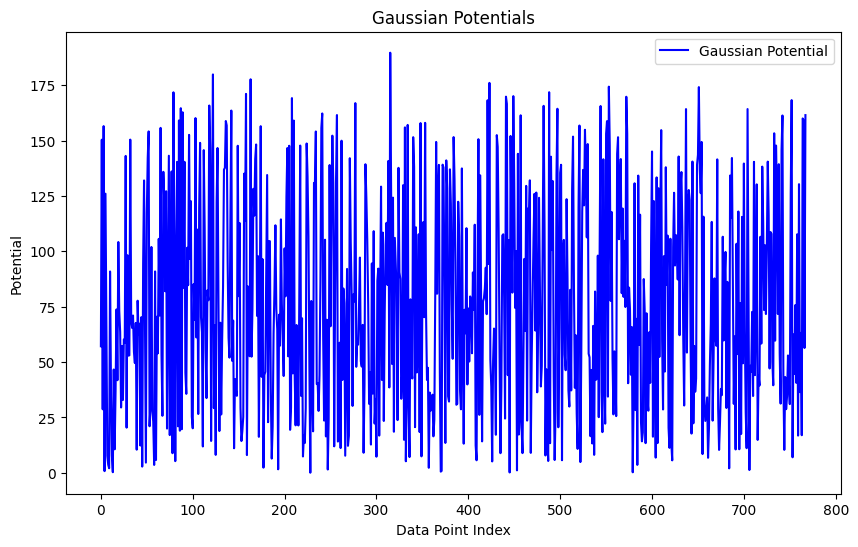

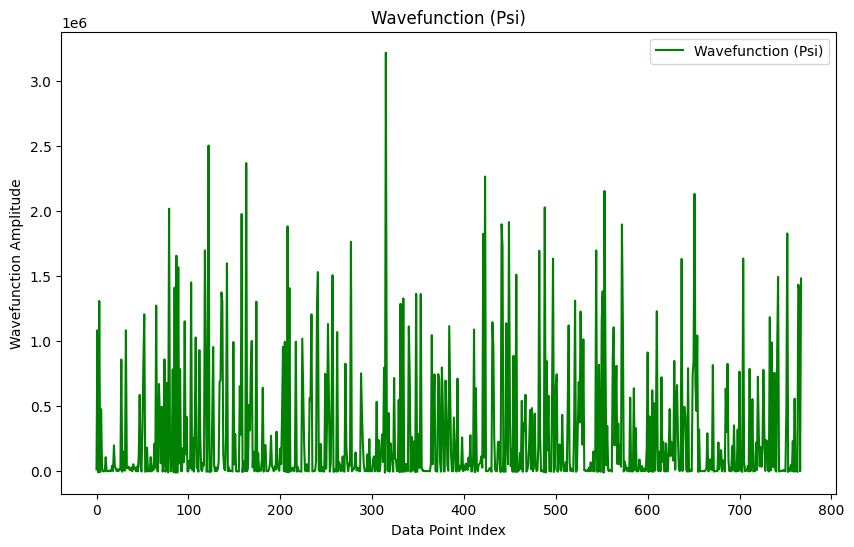

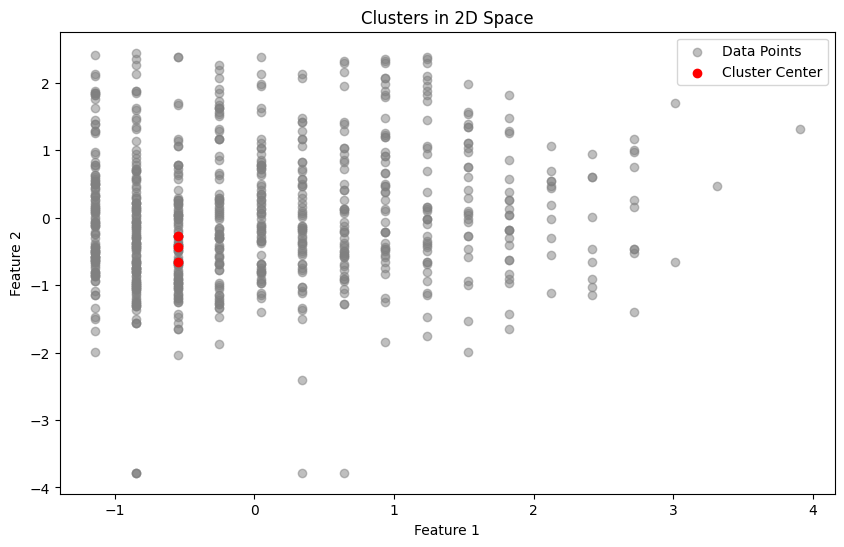

In [3]:
import kagglehub
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# Step 0: Download the dataset using kagglehub
path = kagglehub.dataset_download("mathchi/diabetes-data-set")
print("Path to dataset files:", path)

# Load the dataset from the downloaded path
filename = path + "/diabetes.csv"  # Adjust the filename if necessary

# Step 1: Load and preprocess the diabetes dataset
def load_data(filename):
    data = pd.read_csv(filename)
    # Drop non-numerical columns if present
    numerical_data = data.select_dtypes(include=[np.number])
    # Normalize the data
    normalized_data = (numerical_data - numerical_data.mean()) / numerical_data.std()
    return normalized_data.to_numpy()

# Step 2: Compute Euclidean distance
def euclidean_distance(point1, point2):
    distance = np.sum((np.array(point1) - np.array(point2))**2)
    return distance

# Step 3: Compute Gaussian potential
def gaussian_potential(data, sigma):
    potentials = []
    for i, point_i in enumerate(data):
        potential = 0
        for j, point_j in enumerate(data):
            if i != j:
                distance_squared = euclidean_distance(point_i, point_j)
                gaussian_value = math.exp(-distance_squared / (2 * sigma**2))
                potential += gaussian_value
        potentials.append(potential)
    return potentials

# Step 4: Compute Laplacian
def compute_laplacian(grid, h):
    laplacian = []
    n = len(grid)
    for i in range(n):
        if 0 < i < n - 1:
            value = (grid[i - 1] - 2 * grid[i] + grid[i + 1]) / h**2
        else:
            value = 0  # Boundary conditions
        laplacian.append(value)
    return laplacian

# Step 5: Schrödinger solver
def schrodinger_solver(potentials, h):
    psi = [1.0 for _ in potentials]  # Initial wavefunction
    m, hbar = 1.0, 1.0
    for iteration in range(5):  # Adjust iterations for convergence
        laplacian = compute_laplacian(psi, h)
        for i in range(len(potentials)):
            psi[i] = psi[i] + 0.1 * (-hbar**2 / (2 * m) * laplacian[i] + potentials[i] * psi[i])
    return psi

# Step 6: Identify clusters
def find_clusters(psi):
    probabilities = [abs(val)**2 for val in psi]
    threshold = 0.5 * max(probabilities)  # Define a threshold for high-probability regions
    clusters = [i for i, prob in enumerate(probabilities) if prob > threshold]
    return clusters

# Step 7: Visualization
def visualize_results(data, potentials, psi, clusters):
    # Visualize Gaussian Potentials
    plt.figure(figsize=(10, 6))
    plt.plot(potentials, label="Gaussian Potential", color="blue")
    plt.title("Gaussian Potentials")
    plt.xlabel("Data Point Index")
    plt.ylabel("Potential")
    plt.legend()
    plt.show()

    # Visualize Wavefunction (Psi)
    plt.figure(figsize=(10, 6))
    plt.plot(psi, label="Wavefunction (Psi)", color="green")
    plt.title("Wavefunction (Psi)")
    plt.xlabel("Data Point Index")
    plt.ylabel("Wavefunction Amplitude")
    plt.legend()
    plt.show()

    # Visualize Clusters
    data_2d = data[:, :2]  # Use the first two dimensions for visualization
    plt.figure(figsize=(10, 6))
    plt.scatter(data_2d[:, 0], data_2d[:, 1], label="Data Points", alpha=0.5, color="gray")
    for cluster_idx in clusters:
        plt.scatter(data_2d[cluster_idx, 0], data_2d[cluster_idx, 1], color="red", label="Cluster Center" if cluster_idx == clusters[0] else "")
    plt.title("Clusters in 2D Space")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# Main Program
sigma = 1.5  # Gaussian smoothing parameter
h = 1.0      # Grid spacing

# Load and preprocess the data
data_points = load_data(filename)

# Step 1: Compute Gaussian Potentials
potentials = gaussian_potential(data_points, sigma)
print("\nGaussian Potentials:", potentials)

# Step 2: Solve Schrödinger Equation
psi = schrodinger_solver(potentials, h)
print("\nWavefunction (Psi):", psi)

# Step 3: Find Clusters
clusters = find_clusters(psi)
print("\nCluster Centers (indices):", clusters)
print("Cluster Centers (points):", [data_points[i] for i in clusters])

# Step 4: Visualize Results
visualize_results(data_points, potentials, psi, clusters)


In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.
